<a href="https://colab.research.google.com/github/karimamzghi/cifar10-cnn-classification-project/blob/main/baseline_cnn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [28]:
!git clone https://github.com/karimamzghi/cifar10-cnn-classification-project.git
%cd cifar10-cnn-classification-project

Cloning into 'cifar10-cnn-classification-project'...
remote: Enumerating objects: 63, done.
remote: Counting objects: 100% (63/63), done.
remote: Compressing objects: 100% (52/52), done.
remote: Total 63 (delta 26), reused 20 (delta 3), pack-reused 0 (from 0)
Receiving objects: 100% (63/63), 145.68 KiB | 9.10 MiB/s, done.
Resolving deltas: 100% (26/26), done.
/content/cifar10-cnn-classification-project/cifar10-cnn-classification-project/cifar10-cnn-classification-project


# Project 1 - CNN Image Classification

# ***CNN*** Classification Project using CIFAR-10 DataSet

In [29]:
# Import os from python lib
import os

# Import numpy lib
import numpy as np

# Imports matptotlib lib
import matplotlib.pyplot as plt

# Imports tensorflow.Keras lib
import keras as keras
from keras import layers
from keras.datasets import cifar10
from keras.models import Sequential
from keras.utils import to_categorical
from keras.backend import clear_session
from keras.layers import Dense, Dropout, Flatten
from keras.layers import Conv2D, MaxPooling2D
from keras.optimizers import SGD

# Imports seaborn lib
import seaborn as sns

# Imports sklearn lib
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix

# Imports custom files aka config, experiment files, etc
from src import config
from src.experiment_tracker import save_experiment_results    

In [30]:
# Load CIFAR-10 dataset
(x_train, y_train), (x_test, y_test) = cifar10.load_data()

In [31]:
# Verify and check the data by calling shape of the data
print("x_train: ", x_train.shape)
print("y_train: ", y_train.shape)

print("x_test: ", x_test.shape)
print("y_test: ", y_test.shape)

x_train:  (50000, 32, 32, 3)
y_train:  (50000, 1)
x_test:  (10000, 32, 32, 3)
y_test:  (10000, 1)


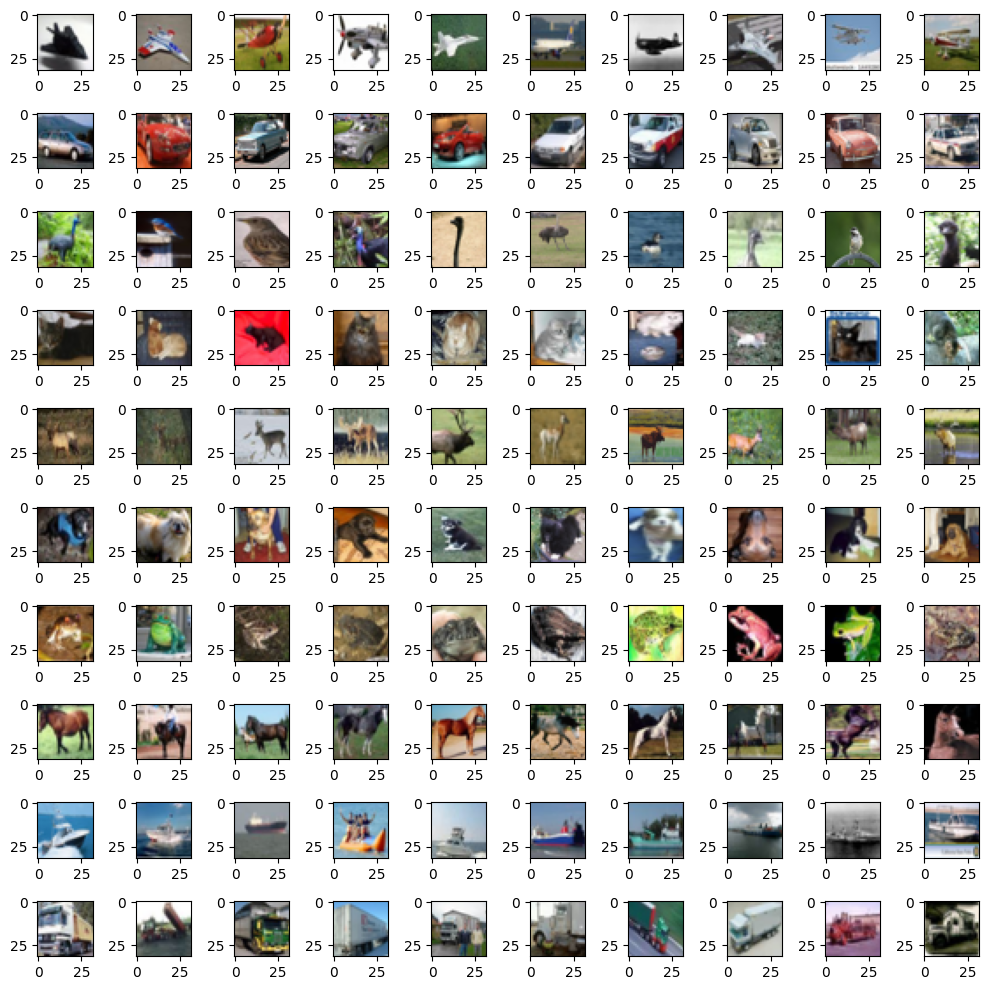

In [32]:
# Add image visualization utilities
plt.figure(figsize=(10, 10))

for class_id in range(10):
    class_indices = np.where(y_train == class_id)[0]
    for sample_idx in range(10):
        # Calculate the 1-indexed grid position (1 to 100)
        position = (class_id * 10) + sample_idx + 1
        img_index = class_indices[sample_idx]

        plt.subplot(10, 10, position)
        plt.imshow(x_train[img_index])
        plt.axis('on')

plt.tight_layout()
plt.show()

In [33]:
# Convert labels from (50000, 1) to (50000,)
y_train = y_train.reshape(-1)
y_test = y_test.reshape(-1)

In [34]:
# Combine full dataset — Keras' default 50k/10k split isn't 70/15/15
x_all = np.concatenate([x_train, x_test], axis=0)
y_all = np.concatenate([y_train, y_test], axis=0)
y_all = y_all.reshape(-1)  # (60000, 1) → (60000,)

# Step 1: carve off 15% for test
x_temp, x_test, y_temp, y_test = train_test_split(
    x_all, y_all,
    test_size=0.15,
    random_state=42,
    stratify=y_all,
    shuffle=True
)

# Step 2: from the remaining 85%, carve off val so it equals 15% of the ORIGINAL total
val_ratio = 0.15 / 0.85  # ≈ 0.1765
x_train, x_val, y_train, y_val = train_test_split(
    x_temp, y_temp,
    test_size=val_ratio,
    random_state=42,
    stratify=y_temp,
    shuffle=True
)

print("x_train:", x_train.shape)  # ~42000
print("x_val:  ", x_val.shape)    # ~9000
print("x_test: ", x_test.shape)   # ~9000

x_train: (42000, 32, 32, 3)
x_val:   (9000, 32, 32, 3)
x_test:  (9000, 32, 32, 3)


In [35]:
# Normalising the data by dividing every pixel by 255.
# Image pixels from will displayed with values range from 0-1 instead of  0-255
x_train = x_train.astype('float32')
x_val = x_val.astype('float32')
x_test = x_test.astype('float32')
x_train /= 255
x_val /= 255
x_test /= 255

print("Train Data after normalisation: ", x_train[:10])
print("Validation Data after normalisation: ", x_val[:10])
print("Test Data after normalisation: ", x_test[:10])

print("x_train min:", x_train.min())
print("x_train max:", x_train.max())
print("x_train dtype:", x_train.dtype)

Train Data after normalisation:  [[[[0.41960785 0.34117648 0.29411766]
   [0.49019608 0.41960785 0.37254903]
   [0.4862745  0.41568628 0.36862746]
   ...
   [0.25882354 0.1882353  0.14509805]
   [0.1882353  0.14117648 0.09411765]
   [0.12156863 0.09411765 0.06666667]]

  [[0.43529412 0.3529412  0.30980393]
   [0.4862745  0.41568628 0.36862746]
   [0.43529412 0.3647059  0.31764707]
   ...
   [0.58431375 0.48235294 0.3764706 ]
   [0.3137255  0.26666668 0.19607843]
   [0.11764706 0.09411765 0.05882353]]

  [[0.4627451  0.38039216 0.3372549 ]
   [0.5137255  0.4392157  0.4       ]
   [0.45882353 0.3882353  0.34509805]
   ...
   [0.6745098  0.5764706  0.4509804 ]
   [0.3529412  0.30588236 0.25882354]
   [0.10980392 0.08627451 0.05098039]]

  ...

  [[0.22745098 0.20392157 0.21960784]
   [0.15686275 0.14901961 0.16078432]
   [0.13725491 0.13333334 0.14901961]
   ...
   [0.10588235 0.09411765 0.08235294]
   [0.11764706 0.10196079 0.09019608]
   [0.12156863 0.10588235 0.09411765]]

  [[0.172549

In [36]:
# Feature Engineering: Hardcoding labels using one-hot encoding
# Perform one-hot encoding for 10 classes
y_train = to_categorical(y_train, num_classes=config.NUM_CLASSES)
y_val = to_categorical(y_val, num_classes=config.NUM_CLASSES)
y_test = to_categorical(y_test, num_classes=config.NUM_CLASSES)

print("Train Data after encoding: ", y_train[:10])
print("\nValidation Data after encoding: ", y_val[:10])
print("\nTest Data after encoding: ", y_test[:10])

Train Data after encoding:  [[0. 0. 1. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 1. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 1. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 1. 0. 0. 0. 0.]
 [0. 0. 0. 1. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 1. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 1. 0. 0.]
 [0. 0. 0. 0. 0. 0. 1. 0. 0. 0.]
 [1. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 1. 0. 0. 0. 0. 0. 0. 0. 0.]]

Validation Data after encoding:  [[0. 0. 0. 0. 0. 0. 0. 1. 0. 0.]
 [0. 0. 0. 1. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 1. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 1.]
 [0. 0. 0. 0. 1. 0. 0. 0. 0. 0.]
 [0. 0. 1. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 1. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 1. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 1. 0. 0.]
 [0. 0. 1. 0. 0. 0. 0. 0. 0. 0.]]

Test Data after encoding:  [[0. 1. 0. 0. 0. 0. 0. 0. 0. 0.]
 [1. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 1. 0.]
 [0. 0. 0. 0. 0. 1. 0. 0. 0. 0.]
 [0. 0. 0. 0. 1. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 1. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 1.]
 [0. 1. 0. 0. 0. 

In [37]:
# Clear any previous TensorFlow models from memory as TensorFlow can accumulate unnecessary objects in memory,
# especially if we are creating many models while tuning hyperparameters.
clear_session()

In [38]:
# Build the Baseline CNN Model

# Initialize and define the model
baseline_model = keras.Sequential(
    [
        keras.Input(shape=config.INPUT_SHAPE),

        layers.Conv2D(32, kernel_size=(3, 3), activation="relu"),
        layers.MaxPooling2D(pool_size=(2, 2)),

        layers.Conv2D(64, kernel_size=(3, 3), activation="relu"),
        layers.MaxPooling2D(pool_size=(2, 2)),

        layers.Flatten(),

        layers.Dense(64, activation="relu"),
        layers.Dense(config.NUM_CLASSES, activation="softmax"),
    ],
    name="baseline_cnn"
)

# Display the model params
baseline_model.summary()

Model: "baseline_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2304)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │       147,520 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 167,562 (654.54 KB)

 Trainable params: 167,562 (654.54 KB)

 Non-trainable params: 0 (0.00 B)

In [39]:
# Compile the model using categorical_crossentropy loss, SGD optimizer and use 'accuracy' as the metric
baseline_model.compile(
    optimizer=SGD(learning_rate=config.LEARNING_RATE),
    loss=config.CATEGORICAL_CROSSENTROPY,
    metrics=[config.ACCURACY]
)

In [40]:
# Train the model using the training data and validate it using the validation data
history = baseline_model.fit(
    x_train,
    y_train,
    batch_size=config.BATCH_SIZE,
    epochs=config.EPOCHS,
    validation_data=(x_val, y_val),
    verbose=1
)

Epoch 1/20
657/657 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.1035 - loss: 2.2958 - val_accuracy: 0.1110 - val_loss: 2.2868
Epoch 2/20
657/657 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.1171 - loss: 2.2777 - val_accuracy: 0.1221 - val_loss: 2.2698
Epoch 3/20
657/657 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.1414 - loss: 2.2581 - val_accuracy: 0.1602 - val_loss: 2.2458
Epoch 4/20
657/657 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.1806 - loss: 2.2263 - val_accuracy: 0.1973 - val_loss: 2.2061
Epoch 5/20
657/657 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.2247 - loss: 2.1787 - val_accuracy: 0.2353 - val_loss: 2.1509
Epoch 6/20
657/657 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.2607 - loss: 2.1181 - val_accuracy: 0.2753 - val_loss: 2.0856
Epoch 7/20
657/657 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.2772 - loss: 2.0580 - val_accuracy: 0.2756 - val_loss: 2.0331
Epoch 8/20
657/657 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.2871 - loss: 2.0156 - val_accuracy: 0.

In [41]:
# Sanity check: confirm we're using the new 70/15/15 split (15% of 60,000 = 9,000) and not the original Keras default test set (10,000)
print("x_test shape:", x_test.shape)
print("Expected: ~9000 (15% of 60000)")

# Evaluate the baseline model on the held-out test set 
test_loss, test_accuracy = baseline_model.evaluate(x_test, y_test)
print("\nTest loss:", test_loss)
print("Test accuracy:", test_accuracy)

x_test shape: (9000, 32, 32, 3)
Expected: ~9000 (15% of 60000)
282/282 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.3710 - loss: 1.7830

Test loss: 1.7829903364181519
Test accuracy: 0.3709999918937683


In [53]:
# Save the model under the models directory defined in config.py
os.makedirs(config.MODELS_DIR, exist_ok=True)
baseline_model.save(f"{config.MODELS_DIR}/model_1_baseline_cnn.keras")

print("Model saved to: ", f"{config.MODELS_DIR}/model_1_baseline_cnn.keras")

Model saved to:  models/model_1_baseline_cnn.keras


282/282 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


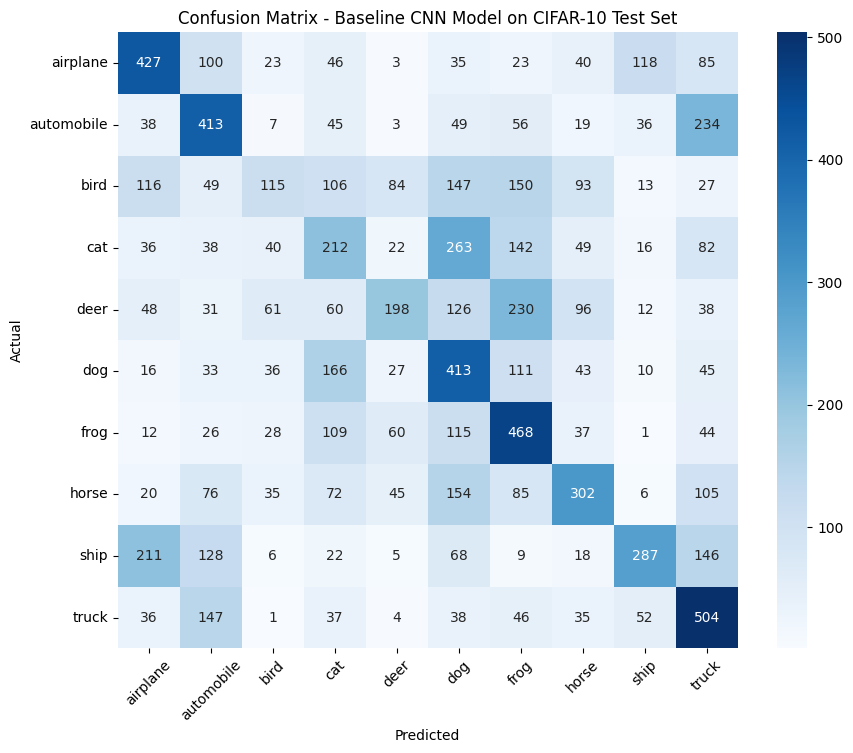

Confusion matrix saved to: results/confusion_matrices/model_1_baseline_cnn_confusion_matrix.png


In [57]:
# Draw the confusion matrix for the test set predictions
MODEL_ID = 1
MODEL_NAME = "baseline_cnn"

class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer', 
               'dog', 'frog', 'horse', 'ship', 'truck']

test_labels = np.argmax(y_test, axis=1)
test_predictions = np.argmax(baseline_model.predict(x_test), axis=1)

# Plot confusion matrix for the test set predictions
cm = confusion_matrix(test_labels, test_predictions)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', 
            xticklabels=class_names, 
            yticklabels=class_names,
            cmap='Blues')
plt.title('Confusion Matrix - Baseline CNN Model on CIFAR-10 Test Set')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.xticks(rotation=45)

# Save the plot
os.makedirs("results/confusion_matrices", exist_ok=True)
confusion_matrix_path = (f"results/confusion_matrices/model_{MODEL_ID}_{MODEL_NAME}_confusion_matrix.png")
plt.savefig(confusion_matrix_path, bbox_inches="tight")
plt.show()

print("Confusion matrix saved to:", confusion_matrix_path)

In [72]:
# Save the experiment results to a CSV file for tracking and analysis
model_path = f"models/{MODEL_NAME}.keras"
baseline_model.save(model_path)

experiment = {
    "model_id": 1,
    "model_name": "baseline_cnn",
    "architecture": "Conv2D(32) + MaxPool + Conv2D(64) + MaxPool + Dense(64)",
    "augmentation": "No",
    "transfer_learning": "No",
    "optimizer": "SGD",
    "learning_rate": config.LEARNING_RATE,
    "batch_size": config.BATCH_SIZE,
    "epochs": len(history.history["accuracy"]),
    "train_accuracy": history.history["accuracy"][-1],
    "validation_accuracy": history.history["val_accuracy"][-1],
    "test_accuracy": test_accuracy,
    "train_loss": history.history["loss"][-1],
    "validation_loss": history.history["val_loss"][-1],
    "test_loss": test_loss,
    "model_path": model_path,
    "confusion_matrix_path": confusion_matrix_path,
    "notes": "Baseline CNN trained from scratch using SGD optimizer"
}

results_df = save_experiment_results(
    experiment,
    config.RESULTS_PATH
)

results_df

,model_id,model_name,architecture,augmentation,transfer_learning,optimizer,learning_rate,batch_size,epochs,train_accuracy,validation_accuracy,test_accuracy,train_loss,validation_loss,test_loss,model_path,confusion_matrix_path,notes
0,1,baseline_cnn,Conv2D(32) + MaxPool + Conv2D(64) + MaxPool + ...,No,No,SGD,0.001,64,20,0.379071,0.374889,0.371,1.782614,1.7795,1.78299,models/baseline_cnn.keras,results/confusion_matrices/model_1_baseline_cn...,Baseline CNN trained from scratch using SGD op...


In [76]:
print(os.listdir("results"))
print(os.listdir("results/confusion_matrices") if os.path.exists("results/confusion_matrices") else "confusion_matrices folder missing")
print(os.path.getsize(config.RESULTS_PATH) if os.path.exists(config.RESULTS_PATH) else "CSV missing")

['model_tracking.csv', 'confusion_matrices']
['model_1_baseline_cnn_confusion_matrix.png']
588


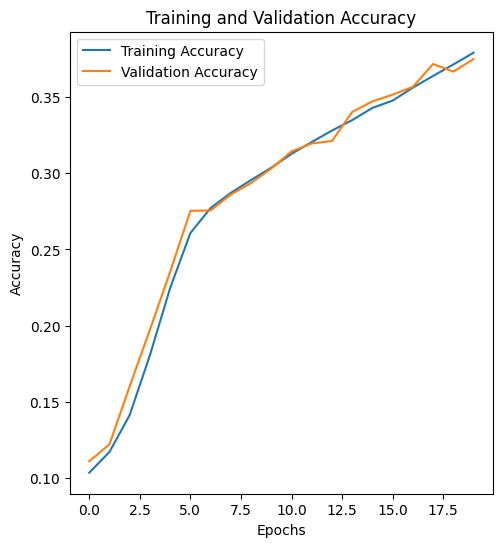

In [87]:
# draw a plot of the training and validation accuracy over epochs
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

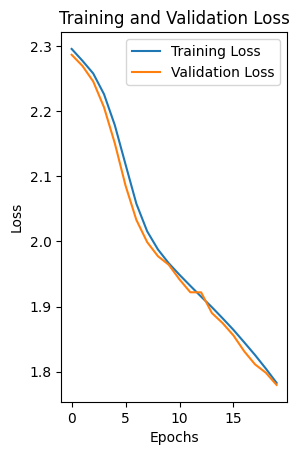

In [65]:
# Draw the training and validation loss over epochs
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')    
plt.ylabel('Loss')
plt.legend()

In [96]:
from google.colab import files

files.download("results/model_tracking.csv")
files.download("results/confusion_matrices/model_1_baseline_cnn_confusion_matrix.png")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>